In [1]:
import cv2
import dlib
import numpy as np
from imutils import face_utils

In [11]:
import pandas as pd
labels_df = pd.read_csv("../recordings_log.csv")  # Update with your actual filename
labels_df.columns = labels_df.columns.str.strip().str.replace(" ", "_")
labels_df.head()
labels_df = labels_df.dropna(subset=["Outcome"])

In [12]:
# Load dlib's models
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

In [25]:
import os

landmark_data = []
frame_interval = 30

for _, row in labels_df.iterrows():
    video_file = "../" + row["Video_Filename"].replace("\\", "/")
    label = int(row["Outcome"])
    video_name = video_file.split("/")[-1]

    # ✅ Check video file existence
    if not os.path.exists(video_file):
        print(f"❌ File not found: {video_file}")
        continue

    cap = cv2.VideoCapture(video_file)
    frame_count = 0
    successful_faces = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        if frame_count % frame_interval != 0:
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype("uint8")
        faces = detector(gray)

        # 🧪 Log if no faces are detected
        if len(faces) == 0:
            print(f"⚠️ No faces detected — {video_name}, frame {frame_count}")
            continue

        for rect in faces:
            shape = predictor(gray, rect)
            shape_np = face_utils.shape_to_np(shape)
            vector = shape_np.flatten()

            landmark_data.append({
                "video": video_name,
                "frame": frame_count,
                "label": label,
                **{f"pt_{i}": val for i, val in enumerate(vector)}
            })
            successful_faces += 1

    cap.release()
    print(f"✅ Processed {video_name} — frames scanned: {frame_count}, faces extracted: {successful_faces}")


✅ Processed clip_20250722_124710.avi — frames scanned: 196, faces extracted: 6
✅ Processed clip_20250722_124740.avi — frames scanned: 133, faces extracted: 4
✅ Processed clip_20250722_124811.avi — frames scanned: 183, faces extracted: 6
✅ Processed clip_20250722_124825.avi — frames scanned: 155, faces extracted: 5
✅ Processed clip_20250722_124846.avi — frames scanned: 202, faces extracted: 6
✅ Processed clip_20250722_124908.avi — frames scanned: 145, faces extracted: 4
✅ Processed clip_20250722_124927.avi — frames scanned: 220, faces extracted: 7
✅ Processed clip_20250722_125014.avi — frames scanned: 153, faces extracted: 5
✅ Processed clip_20250722_125035.avi — frames scanned: 198, faces extracted: 6
✅ Processed clip_20250722_125124.avi — frames scanned: 162, faces extracted: 5
✅ Processed clip_20250722_125144.avi — frames scanned: 176, faces extracted: 5
✅ Processed clip_20250722_125206.avi — frames scanned: 153, faces extracted: 5
✅ Processed clip_20250722_125242.avi — frames scanne

In [26]:
df_landmarks = pd.DataFrame(landmark_data)
df_landmarks.to_csv("video_landmark_data.csv", index=False)

print(f"✅ Saved {len(df_landmarks)} samples from {len(labels_df)} video clips.")

✅ Saved 286 samples from 62 video clips.


In [10]:
# Path to video file
video_path = "C:/Users/connellj2/OneDrive - Wentworth Institute of Technology/Documents/DecepTech/CroppedClips/clip_20250721_133055.avi"

# Initialize video capture
cap = cv2.VideoCapture(video_path)

# Storage for extracted vectors
landmark_vectors = []

# Sampling parameters
frame_interval = 30
frame_count = 0


In [11]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    if frame_count % frame_interval != 0:
        continue

    # Convert to grayscale and ensure format
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = gray.astype('uint8')

    # Detect faces and extract landmarks
    faces = detector(gray)
    for rect in faces:
        shape = predictor(gray, rect)
        shape_np = face_utils.shape_to_np(shape)
        vector = shape_np.flatten()
        landmark_vectors.append({
            "frame": frame_count,
            "landmarks": vector.tolist()
        })

print(f"✅ Extracted {len(landmark_vectors)} landmark vectors.")

cap.release()


✅ Extracted 5 landmark vectors.


In [13]:
!pip install pandas
import pandas as pd

# Flatten the data into rows with frame ID + 136 landmarks
rows = []
for item in landmark_vectors:
    row = {"frame": item["frame"]}
    for i, val in enumerate(item["landmarks"]):
        row[f"pt_{i}"] = val
    rows.append(row)

# Create DataFrame and export
df = pd.DataFrame(rows)
df.to_csv("landmark_vectors_sampled.csv", index=False)

print("✅ Landmark vectors saved to landmark_vectors_sampled.csv")



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/80/a5/3a92893e7399a691bad7664d977cb5e7c81cf666c81f89ea76ba2bff483d/pandas-2.3.1-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for pytz>=2020.1 from https://files.pythonhosted.org/packages/81/c4/34e93fe5f5429d7570ec1fa436f1986fb1f00c3e0f43a589fe2bbcd22c3f/pytz-2025.2-py2.py3-none-any.whl.metadata
  Obtaining dependency information for tzdata>=2022.7 from https://files.pythonhosted.org/packages/5c/23/c7abc0ca0a1526a0774eca151daeb8de62ec457e77262b66b359c3c7679e/tzdata-2025.2-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.2/11.0 MB 5.9 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/11.0 MB 8.0 MB/s eta 0:00:02
   --- ------------------------------------ 1.1/11.0 MB 8.5 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/11.0 MB 10.5 MB/s eta 0:00:01

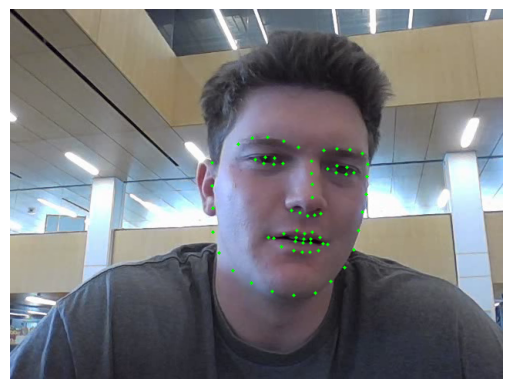

<Figure size 640x480 with 0 Axes>

In [2]:
import cv2
import dlib
from imutils import face_utils
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# Load dlib's face detector and shape predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# Load your video file
video_path = "C:/Users/connellj2/OneDrive - Wentworth Institute of Technology/Documents/DecepTech/CroppedClips/clip_20250721_133055.avi"
cap = cv2.VideoCapture(video_path)

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_count > 100:  # Limit frames for testing
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = gray.astype('uint8')
    faces = detector(gray)

    for rect in faces:
        shape = predictor(gray, rect)
        shape_np = face_utils.shape_to_np(shape)

        for (x, y) in shape_np:
            cv2.circle(frame, (x, y), 2, (0, 255, 0), -1)

    # Convert BGR to RGB for display
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.axis('off')
    clear_output(wait=True)
    display(plt.gcf())
    plt.clf()

    frame_count += 1

cap.release()
